In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset_elpino.csv to dataset_elpino.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")

print("="*50)
print("1. CALIDAD DE LOS DATOS")
print("="*50)
print(f"Dimensiones del dataset: {df.shape[0]} registros (filas) y {df.shape[1]} variables (columnas)\n")
df.replace("-", np.nan, inplace=True)
columnas_clave = ["Edad en años", "Sexo (Desc)", "GRD", "Diag 01 Principal (cod+des)"]
print("Completitud: Cantidad de valores nulos")
print(df[columnas_clave].isnull().sum(), "\n")

print("Correctitud: Tipos de datos")
print(df[columnas_clave].dtypes, "\n")

print("Detección de Outliers en Edad")
Q1 = df["Edad en años"].quantile(0.25)
Q3 = df["Edad en años"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_edad = df[(df["Edad en años"] < limite_inferior) | (df["Edad en años"] > limite_superior)]
print(f"Límites normales calculados: [{limite_inferior}, {limite_superior}]")
print(f"Cantidad de pacientes con edad fuera de este rango normal: {len(outliers_edad)}")
print("Estadísticas de la edad:")
print(df["Edad en años"].describe(), "\n")



1. CALIDAD DE LOS DATOS
Dimensiones del dataset: 14561 registros (filas) y 68 variables (columnas)

Completitud: Cantidad de valores nulos
Edad en años                   0
Sexo (Desc)                    0
GRD                            0
Diag 01 Principal (cod+des)    0
dtype: int64 

Correctitud: Tipos de datos
Edad en años                    int64
Sexo (Desc)                    object
GRD                            object
Diag 01 Principal (cod+des)    object
dtype: object 

Detección de Outliers en Edad
Límites normales calculados: [-32.5, 115.5]
Cantidad de pacientes con edad fuera de este rango normal: 1
Estadísticas de la edad:
count    14561.000000
mean        39.426550
std         24.681545
min          0.000000
25%         23.000000
50%         36.000000
75%         60.000000
max        121.000000
Name: Edad en años, dtype: float64 



/tmp/ipykernel_22211/3020308018.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=completitud.values, y=completitud.index, palette="mako")


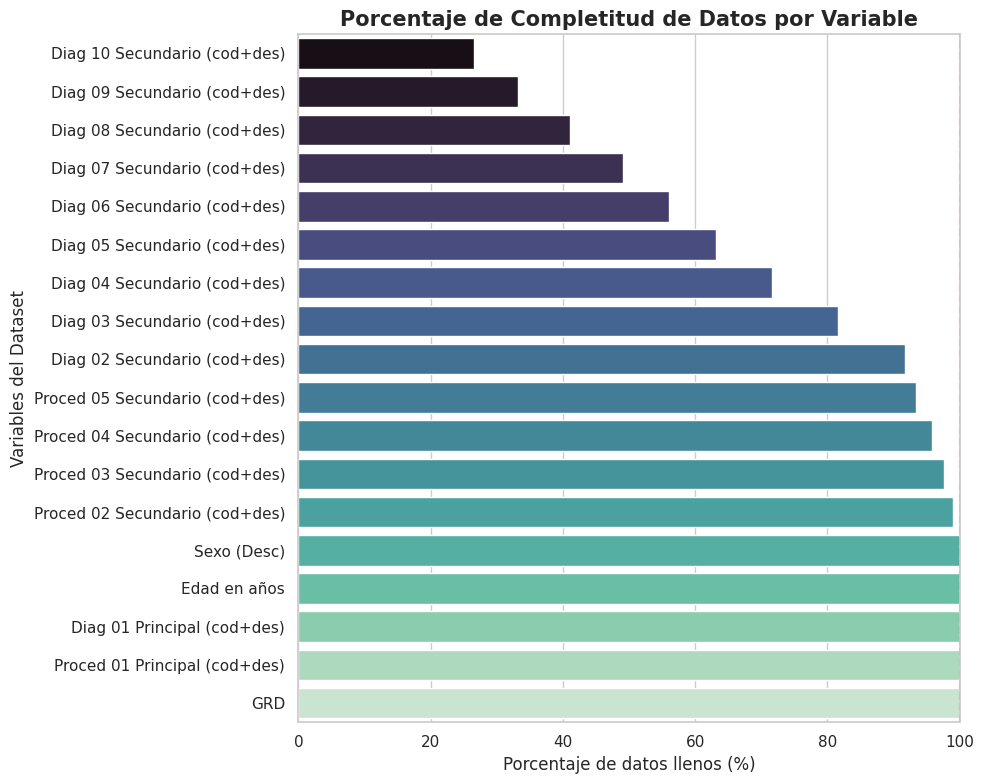

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))

cols_interes = ["Edad en años", "Sexo (Desc)", "GRD"] + \
               [col for col in df.columns if "Diag" in col][:10] + \
               [col for col in df.columns if "Proced" in col][:5]

completitud = (df[cols_interes].notnull().sum() / len(df)) * 100
completitud = completitud.sort_values(ascending=True)

sns.barplot(x=completitud.values, y=completitud.index, palette="mako")
plt.title("Porcentaje de Completitud de Datos por Variable", fontsize=15, fontweight="bold")
plt.xlabel("Porcentaje de datos llenos (%)")
plt.ylabel("Variables del Dataset")
plt.xlim(0, 100)

plt.axvline(x=100, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
print("="*50)
print("2. ESTADÍSTICAS DESCRIPTIVAS")
print("="*50)

print("Distribución por Sexo")
print(df["Sexo (Desc)"].value_counts(dropna=False), "\n")

print("Top 5 GRD más frecuentes")
print(df["GRD"].value_counts().head(5), "\n")

print("Top 5 Diagnósticos Principales (Diag 01)")
print(df["Diag 01 Principal (cod+des)"].value_counts().head(5), "\n")

2. ESTADÍSTICAS DESCRIPTIVAS
Distribución por Sexo
Sexo (Desc)
Mujer     9617
Hombre    4944
Name: count, dtype: int64 

Top 5 GRD más frecuentes
GRD
146101 - PH CESÁREA                                                                       813
146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO    639
146131 - PH PARTO VAGINAL                                                                 538
158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR                       389
134161 - MH TRASTORNOS DEL ANTEPARTO                                                      325
Name: count, dtype: int64 

Top 5 Diagnósticos Principales (Diag 01)
Diag 01 Principal (cod+des)
O70.0 - Desgarro perineal de primer grado durante el parto                       779
O80.0 - Parto único espontáneo, presentación cefálica de vértice                 471
U07.1 - COVID-19, virus identificado                                             327
O34.2 - Atención materna por

/tmp/ipykernel_22211/961439829.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_diag.values, y=nombres_diag_cortos, palette="Reds_r")


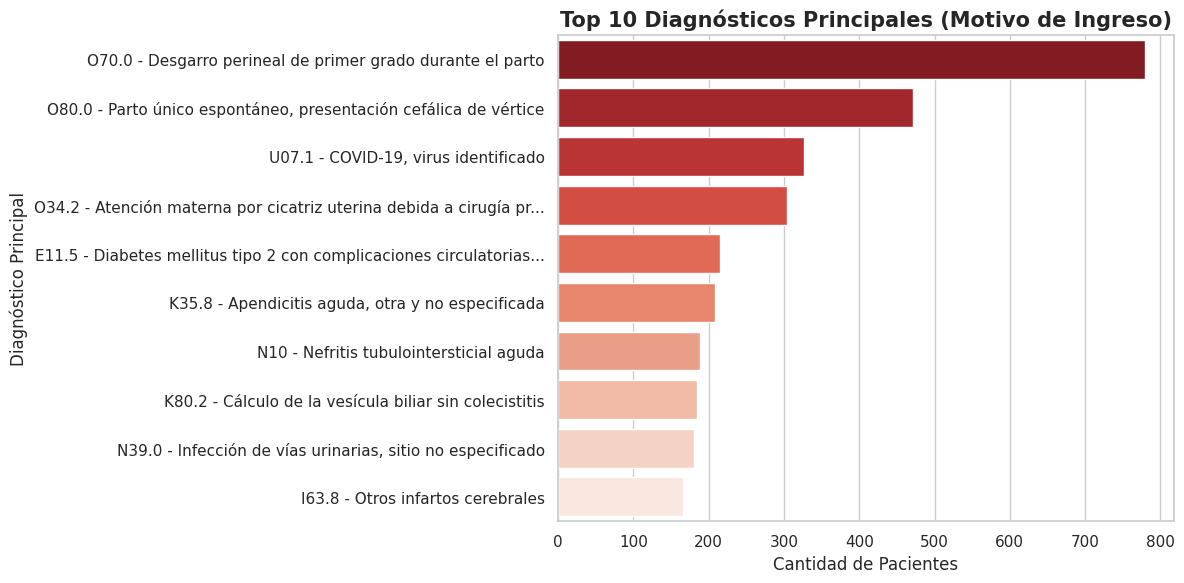

In [ ]:
plt.figure(figsize=(12, 6))

top_10_diag = df["Diag 01 Principal (cod+des)"].value_counts().head(10)

nombres_diag_cortos = [str(x)[:65] + "..." if len(str(x)) > 65 else str(x) for x in top_10_diag.index]

sns.barplot(x=top_10_diag.values, y=nombres_diag_cortos, palette="Reds_r")

plt.title("Top 10 Diagnósticos Principales (Motivo de Ingreso)", fontsize=15, fontweight="bold")
plt.xlabel("Cantidad de Pacientes")
plt.ylabel("Diagnóstico Principal")

plt.tight_layout()
plt.show()

/tmp/ipykernel_22211/599781571.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Sexo (Desc)", y="Edad en años", ax=axes[0, 1], palette="pastel")
/tmp/ipykernel_22211/599781571.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_grd.values, y=nombres_grd_cortos, ax=axes[1, 0], palette="viridis")


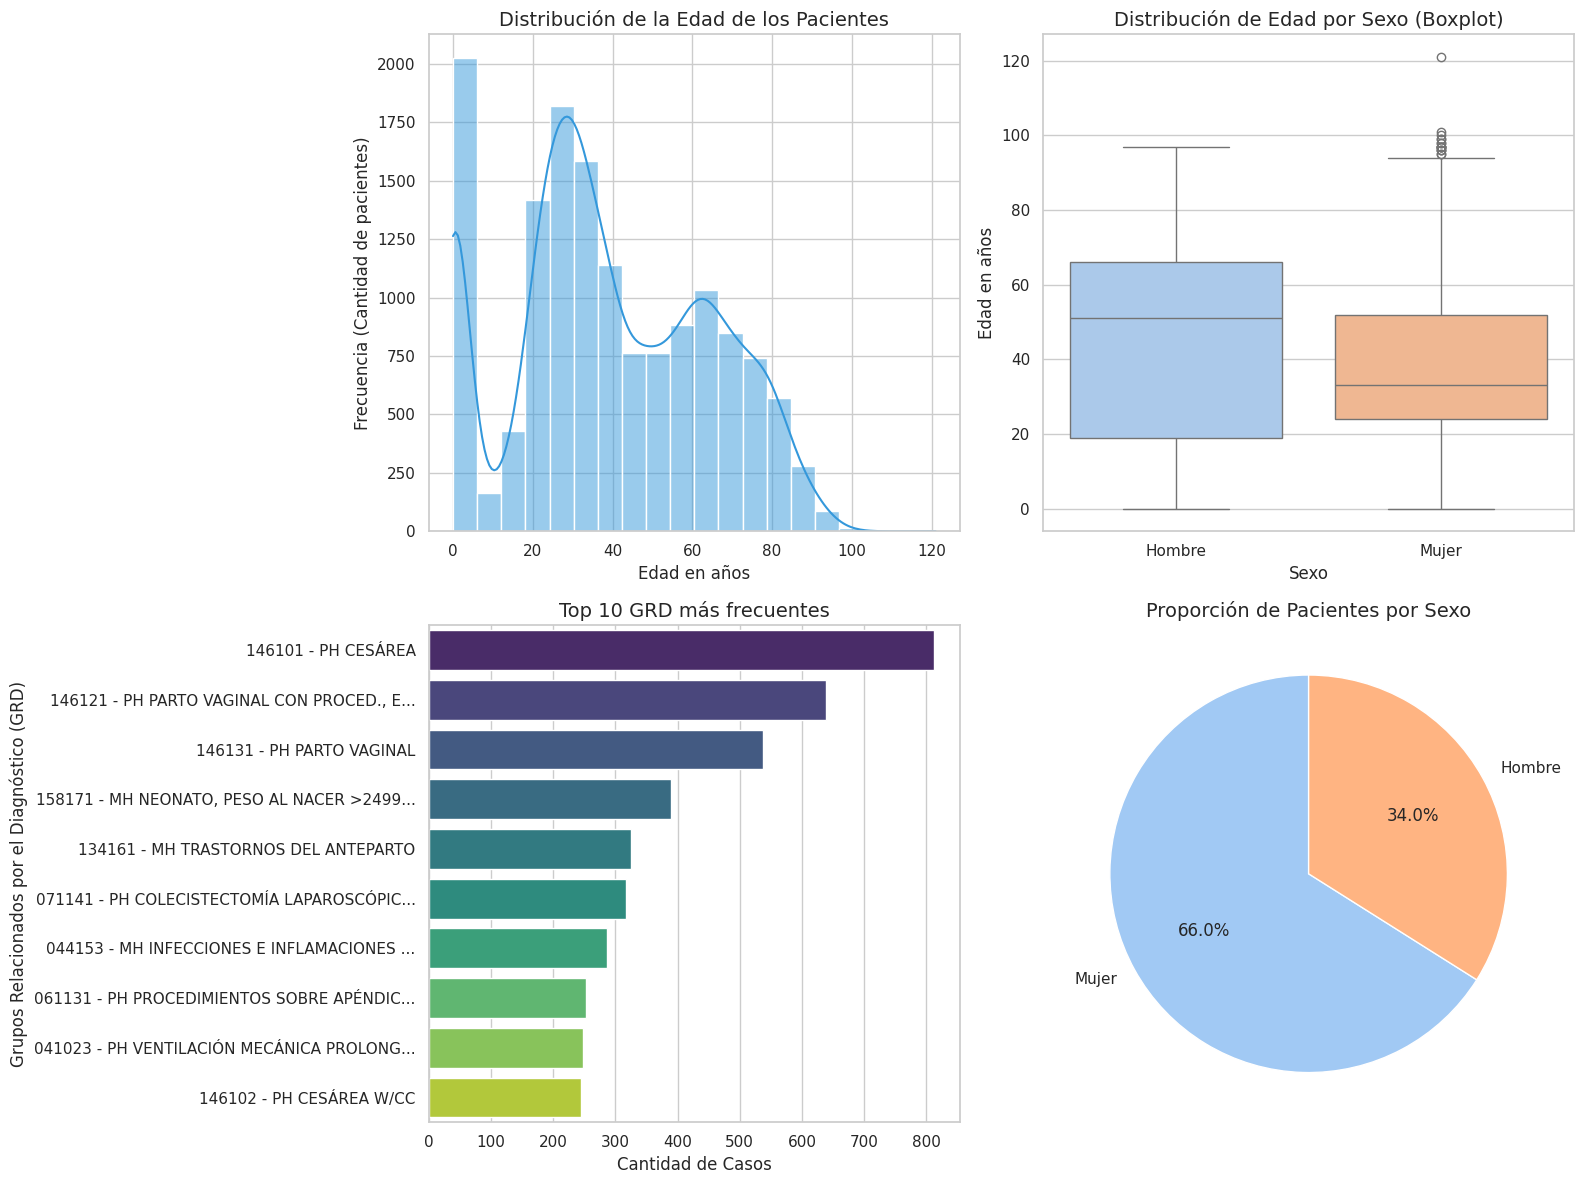

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(data=df, x="Edad en años", kde=True, bins=20, ax=axes[0, 0], color="#3498db")
axes[0, 0].set_title("Distribución de la Edad de los Pacientes", fontsize=14)
axes[0, 0].set_xlabel("Edad en años")
axes[0, 0].set_ylabel("Frecuencia (Cantidad de pacientes)")

sns.boxplot(data=df, x="Sexo (Desc)", y="Edad en años", ax=axes[0, 1], palette="pastel")
axes[0, 1].set_title("Distribución de Edad por Sexo (Boxplot)", fontsize=14)
axes[0, 1].set_xlabel("Sexo")
axes[0, 1].set_ylabel("Edad en años")

top_10_grd = df["GRD"].value_counts().head(10)
nombres_grd_cortos = [str(x)[:40] + "..." if len(str(x)) > 40 else str(x) for x in top_10_grd.index]
sns.barplot(x=top_10_grd.values, y=nombres_grd_cortos, ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title("Top 10 GRD más frecuentes", fontsize=14)
axes[1, 0].set_xlabel("Cantidad de Casos")
axes[1, 0].set_ylabel("Grupos Relacionados por el Diagnóstico (GRD)")

sex_counts = df["Sexo (Desc)"].value_counts()
axes[1, 1].pie(sex_counts.values, labels=sex_counts.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
axes[1, 1].set_title("Proporción de Pacientes por Sexo", fontsize=14)

plt.tight_layout()
plt.show()

/tmp/ipykernel_22211/932190150.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_grd, y="GRD_Corto", x="Edad en años", ax=axes[0], palette="Set2")
/tmp/ipykernel_22211/932190150.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_proc.values, y=nombres_proc, ax=axes[1], palette="magma")


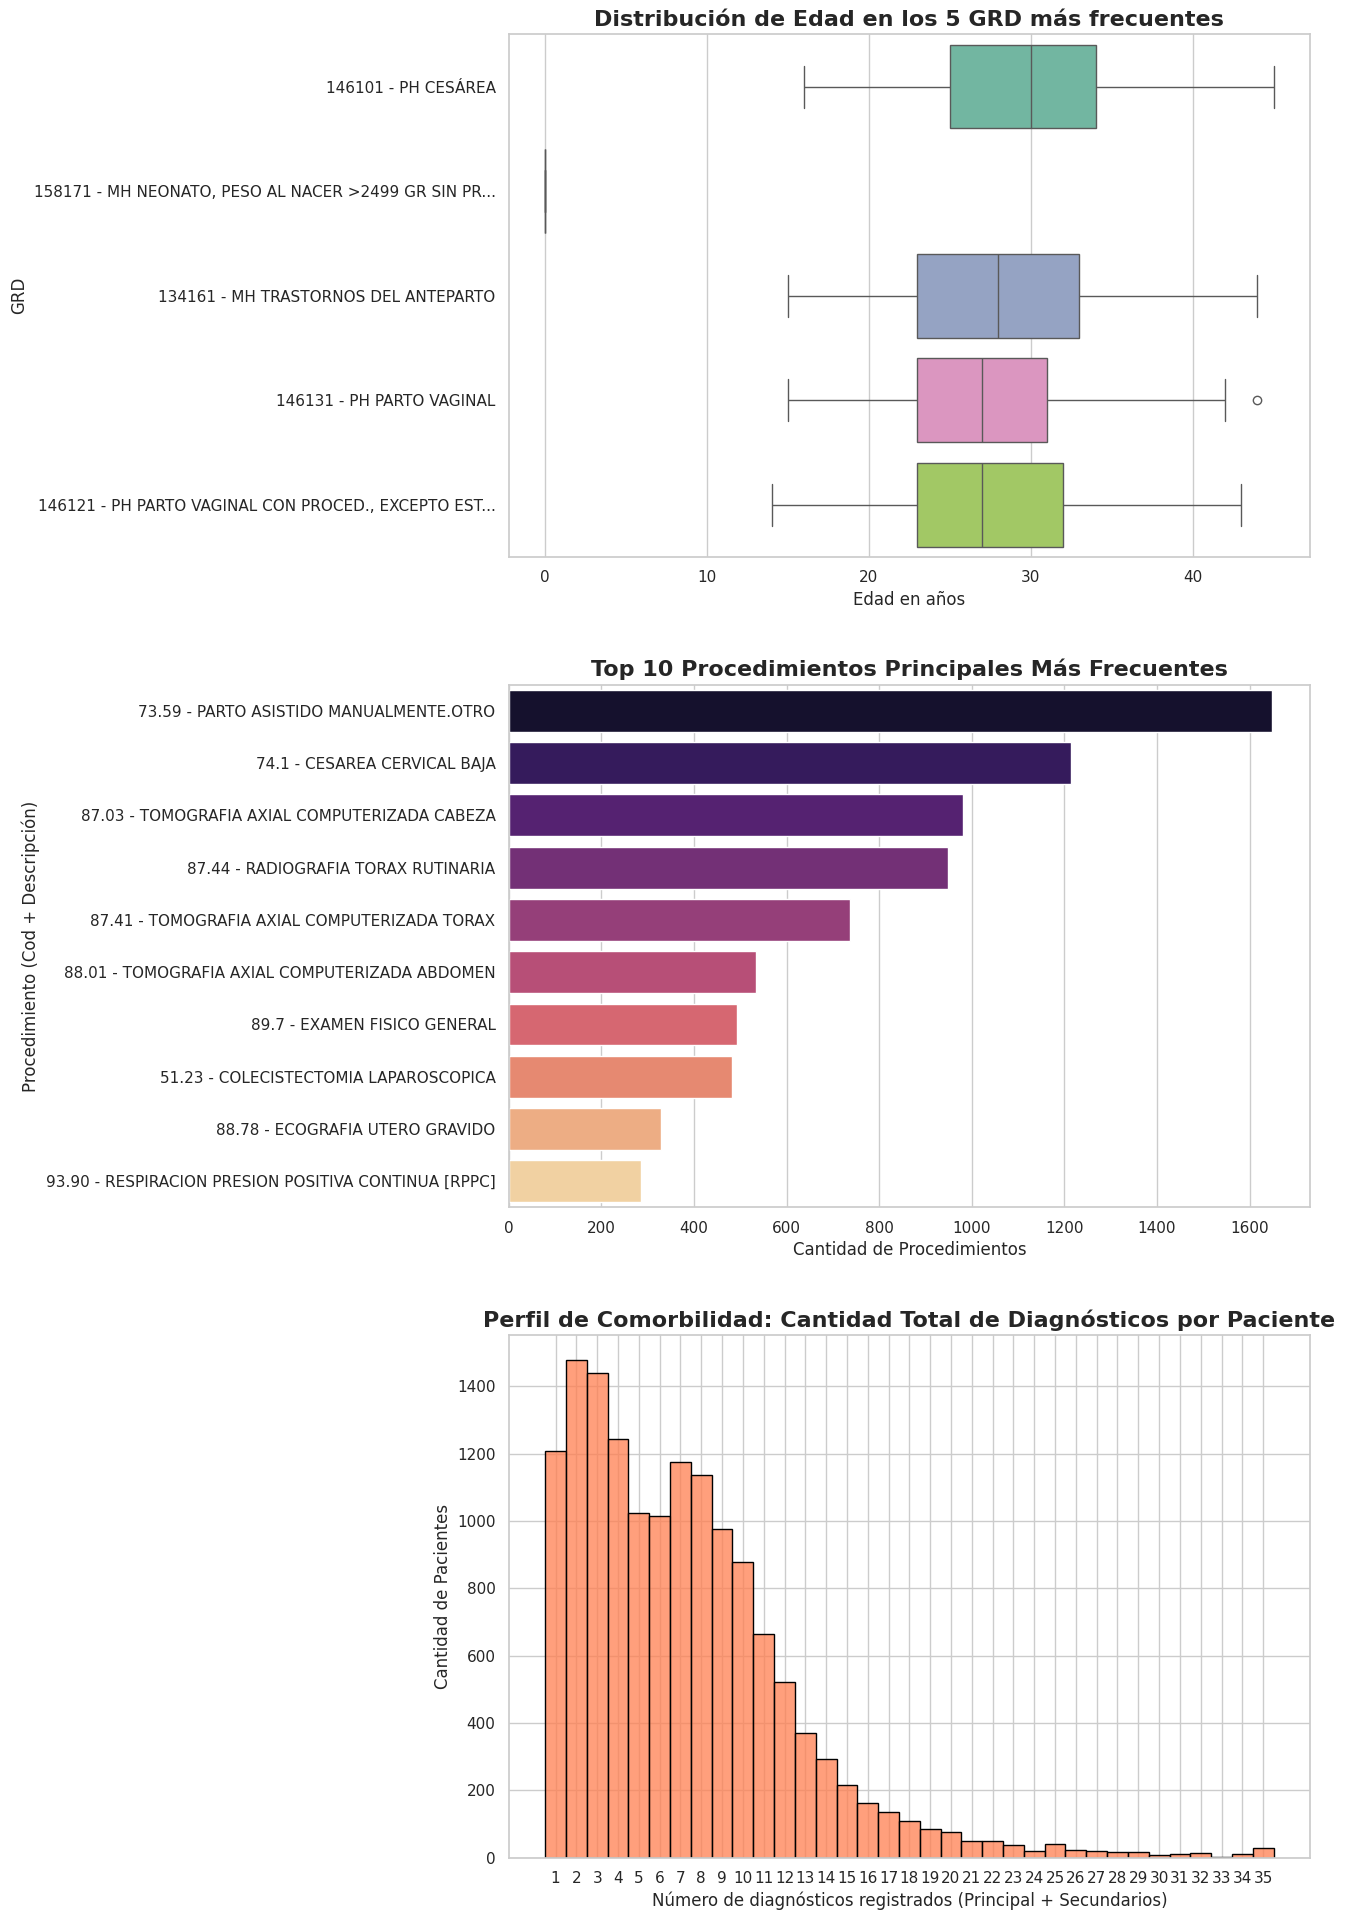

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(14, 20))
top_5_grd = df["GRD"].value_counts().head(5).index
df_top_grd = df[df["GRD"].isin(top_5_grd)].copy()

df_top_grd["GRD_Corto"] = df_top_grd["GRD"].apply(lambda x: str(x)[:50] + "..." if len(str(x)) > 50 else str(x))

sns.boxplot(data=df_top_grd, y="GRD_Corto", x="Edad en años", ax=axes[0], palette="Set2")
axes[0].set_title("Distribución de Edad en los 5 GRD más frecuentes", fontsize=16, fontweight="bold")
axes[0].set_xlabel("Edad en años")
axes[0].set_ylabel("GRD")

df_proced = df.dropna(subset=["Proced 01 Principal (cod+des)"])
top_10_proc = df_proced["Proced 01 Principal (cod+des)"].value_counts().head(10)
nombres_proc = [str(x)[:60] + "..." if len(str(x)) > 60 else str(x) for x in top_10_proc.index]

sns.barplot(x=top_10_proc.values, y=nombres_proc, ax=axes[1], palette="magma")
axes[1].set_title("Top 10 Procedimientos Principales Más Frecuentes", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Cantidad de Procedimientos")
axes[1].set_ylabel("Procedimiento (Cod + Descripción)")

columnas_diag = [col for col in df.columns if "Diag" in col]
df["Total_Diagnosticos_Registrados"] = df[columnas_diag].notnull().sum(axis=1)

sns.histplot(data=df, x="Total_Diagnosticos_Registrados", discrete=True, ax=axes[2], color="coral", edgecolor="black")
axes[2].set_title("Perfil de Comorbilidad: Cantidad Total de Diagnósticos por Paciente", fontsize=16, fontweight="bold")
axes[2].set_xlabel("Número de diagnósticos registrados (Principal + Secundarios)")
axes[2].set_ylabel("Cantidad de Pacientes")
axes[2].set_xticks(range(1, df["Total_Diagnosticos_Registrados"].max() + 1))

plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
# PREPARACION DE DATOS


# Columnas
diag_cols = [col for col in df.columns if "Diag" in col]
proc_cols = [col for col in df.columns if "Proced" in col]

edad_col = "Edad en años"
sexo_col = "Sexo (Desc)"
target_col = "GRD"

# Copia
df_model = df[diag_cols + proc_cols + [edad_col, sexo_col, target_col]].copy()

# Limpieza
df_model[edad_col] = pd.to_numeric(df_model[edad_col], errors="coerce")
df_model[edad_col] = df_model[edad_col].fillna(df_model[edad_col].median())

df_model[sexo_col] = df_model[sexo_col].fillna("Desconocido").astype(str)
df_model = df_model.dropna(subset=[target_col])

for col in diag_cols + proc_cols:
    df_model[col] = df_model[col].fillna("").astype(str)

# Texto combinado
df_model["texto_diag"] = df_model[diag_cols].agg(" ".join, axis=1)
df_model["texto_proc"] = df_model[proc_cols].agg(" ".join, axis=1)

df_final = df_model[[edad_col, sexo_col, "texto_diag", "texto_proc", target_col]].copy()

print(df_final.shape)

(14561, 5)


In [ ]:
# REDUCIR GRD

top_n = 10
top_grd = df_final[target_col].value_counts().head(top_n).index

df_final = df_final[df_final[target_col].isin(top_grd)]

print(df_final[target_col].value_counts())

GRD
146101 - PH CESÁREA                                                                       813
146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO    639
146131 - PH PARTO VAGINAL                                                                 538
158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR                       389
134161 - MH TRASTORNOS DEL ANTEPARTO                                                      325
071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA                                                 317
044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC                               287
061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE                                                 252
041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC                       248
146102 - PH CESÁREA W/CC                                                                  244
Name: count, dtype: int64


In [ ]:
# X e y

from sklearn.preprocessing import LabelEncoder

X = df_final[[edad_col, sexo_col, "texto_diag", "texto_proc"]]
y = df_final[target_col]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
# TRAIN TEST

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
# PREPROCESAMIENTO

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("edad", "passthrough", [edad_col]),
    ("sexo", CountVectorizer(), sexo_col),
    ("diag", CountVectorizer(max_features=200), "texto_diag"),
    ("proc", CountVectorizer(max_features=200), "texto_proc"),
])

In [ ]:
# MODELOS


from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modelos = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [ ]:
# ENTRENAMIENTO

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados = []

for nombre, modelo in modelos.items():

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", modelo)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    resultados.append([nombre, acc, prec, rec, f1])

    print("\nModelo:", nombre)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)


Modelo: LogisticRegression
Accuracy: 0.9654747225647349
Precision: 0.9643243326996929
Recall: 0.9654747225647349
F1: 0.9644172811762726

Modelo: RandomForest
Accuracy: 0.9642416769420469
Precision: 0.9625921670465444
Recall: 0.9642416769420469
F1: 0.9621928485065556


In [ ]:
# RESULTADOS


import pandas as pd

df_resultados = pd.DataFrame(resultados, columns=[
    "Modelo", "Accuracy", "Precision", "Recall", "F1"
])

print(df_resultados)

               Modelo  Accuracy  Precision    Recall        F1
0  LogisticRegression  0.965475   0.964324  0.965475  0.964417
1        RandomForest  0.964242   0.962592  0.964242  0.962193


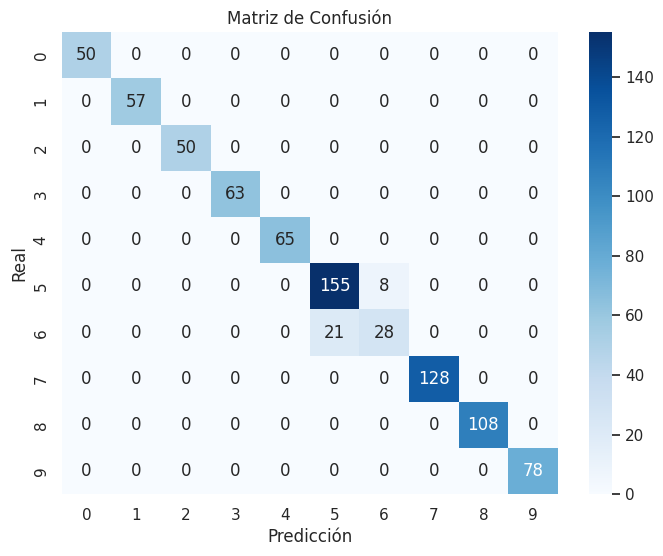

In [ ]:
# MATRIZ DE CONFUSION

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# usar el último modelo (o el mejor)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

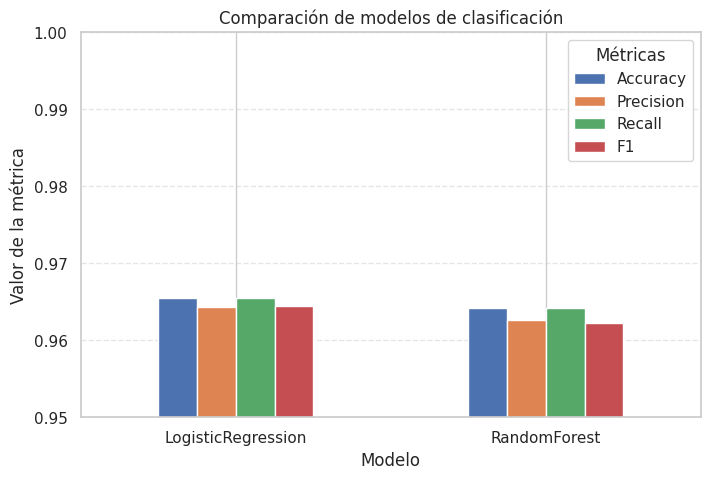

In [ ]:
df_plot.plot(kind="bar", figsize=(8,5))

plt.title("Comparación de modelos de clasificación")
plt.ylabel("Valor de la métrica")
plt.xlabel("Modelo")
plt.ylim(0.95, 1)
plt.xticks(rotation=0)

plt.legend(title="Métricas")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [ ]:
mejor_modelo = df_resultados.sort_values(by="F1", ascending=False).iloc[0]
print("Mejor modelo:", mejor_modelo["Modelo"])

Mejor modelo: LogisticRegression


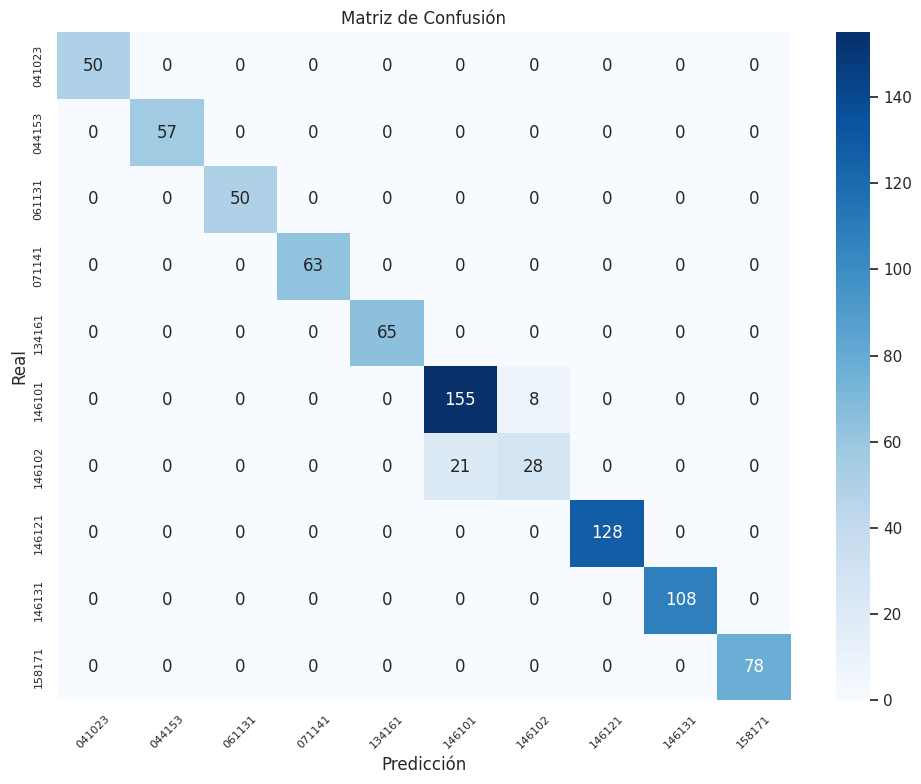

In [ ]:
labels_cortos = [c.split(" - ")[0] for c in le.classes_]

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_cortos,
    yticklabels=labels_cortos
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()